# Lab 3 — Investigate Your Reconstruction

This notebook is the second half of Lab 3. By now you have:
- Captured a video on your phone.
- Extracted PNG frames with `ffmpeg`.
- Run the Colab notebook end-to-end (sparse + dense + mesh).
- Downloaded the `content/` workspace from your Drive to your laptop.

Here we open those COLMAP outputs and check whether the reconstruction is self-consistent: are the cameras where you actually were when you filmed, do the 3D points line up with the images, and where does the dense reconstruction fail? The math sections from the handout (camera model, epipolar constraint, bundle adjustment) get exercised below on your own data.

## Setup

Point `RECON_DIR` at the `content/` folder you downloaded. It should contain `sparse/`, `dense/`, and `database.db`.

In [29]:
from pathlib import Path

# Change this to the path of your downloaded Colab workspace.
RECON_DIR = Path("/Users/azeez/Downloads/content 4")

assert RECON_DIR.exists(), f"Path does not exist: {RECON_DIR}"
print(f"Using reconstruction at: {RECON_DIR}")
print(f"  sparse/   exists : {(RECON_DIR / 'sparse').exists()}")
print(f"  dense/    exists : {(RECON_DIR / 'dense').exists()}")
print(f"  database  exists : {(RECON_DIR / 'database.db').exists()}")

Using reconstruction at: /Users/azeez/Downloads/content 4
  sparse/   exists : True
  dense/    exists : True
  database  exists : True


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
import cv2
import pycolmap
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "vscode"

## Step 1. Load the reconstruction and inspect the summary

COLMAP's sparse mapper sometimes produces more than one sub-model when its matching graph is disconnected. We first peek at the top-level `sparse/` folder to see whether the mapper merged everything into one model. Then, for the analysis below, we load the **undistorted** sparse model from `dense/sparse/`. That model uses a PINHOLE camera (no distortion coefficients) and matches the undistorted JPGs in `dense/images/`, which makes the geometry math cleaner.

In [31]:
# How many sub-models did COLMAP produce?
sparse_subdirs = sorted([d for d in (RECON_DIR / "sparse").iterdir() if d.is_dir()])
print(f"Top-level sparse/ has {len(sparse_subdirs)} sub-model(s): {[d.name for d in sparse_subdirs]}")
for d in sparse_subdirs:
    m = pycolmap.Reconstruction(str(d))
    print(f"  sparse/{d.name}: {m.num_reg_images()} registered images, {m.num_points3D()} 3D points")

if len(sparse_subdirs) > 1:
    print("\nNOTE: COLMAP could not merge everything into one sparse model.")
    print("Look at the frame names in each sub-model to see where your capture path broke.")

Top-level sparse/ has 1 sub-model(s): ['0']
  sparse/0: 20 registered images, 1199 3D points


In [32]:
# Load the undistorted model (the one used by the dense pipeline).
rec = pycolmap.Reconstruction(str(RECON_DIR / "dense" / "sparse"))
print(rec.summary())

Reconstruction:
	num_rigs = 20
	num_cameras = 20
	num_frames = 20
	num_reg_frames = 20
	num_images = 20
	num_points3D = 1199
	num_observations = 4501
	mean_track_length = 3.75396
	mean_observations_per_image = 225.05
	mean_reprojection_error = 0.771747


In [33]:
# Summary stats
errors = [p.error for p in rec.points3D.values()]
track_lengths = [len(p.track.elements) for p in rec.points3D.values()]

print(f"Registered images:      {rec.num_reg_images()}")
print(f"Triangulated 3D points: {rec.num_points3D()}")
print(f"Mean reprojection error: {np.mean(errors):.3f} px")
print(f"Median reprojection error: {np.median(errors):.3f} px")
print(f"Mean track length:       {np.mean(track_lengths):.2f} frames per point")

# What camera model is being used?
for cam_id, cam in rec.cameras.items():
    model_name = cam.model.name if hasattr(cam.model, "name") else str(cam.model)
    print()
    print(f"Camera {cam_id}: {model_name}  ({cam.width} x {cam.height})")
    print(f"  params: {cam.params}")

Registered images:      20
Triangulated 3D points: 1199
Mean reprojection error: 0.772 px
Median reprojection error: 0.667 px
Mean track length:       3.75 frames per point

Camera 23: PINHOLE  (977 x 1738)
  params: [1734.04234529 1734.04234529  488.5         869.        ]

Camera 22: PINHOLE  (1029 x 1831)
  params: [1671.95174465 1671.95174465  514.5         915.5       ]

Camera 8: PINHOLE  (1048 x 1864)
  params: [1428.70840472 1428.70840472  524.          932.        ]

Camera 20: PINHOLE  (964 x 1715)
  params: [1504.29469284 1504.29469284  482.          857.5       ]

Camera 7: PINHOLE  (1010 x 1797)
  params: [1531.42670572 1531.42670572  505.          898.5       ]

Camera 36: PINHOLE  (1038 x 1846)
  params: [1553.09426752 1553.09426752  519.          923.        ]

Camera 19: PINHOLE  (1055 x 1877)
  params: [1704.12244649 1704.12244649  527.5         938.5       ]

Camera 6: PINHOLE  (963 x 1713)
  params: [1430.75467097 1430.75467097  481.5         856.5       ]

Camera 3

**Quick checks:**
1. How many of your input frames were registered? If you extracted 50 frames, did COLMAP place all 50?
2. What is the mean reprojection error? Less than 0.5 px is excellent, more than 1.0 px is suspicious.
3. How many sparse points were triangulated? A few thousand is typical for a well-textured object; a few hundred suggests texture problems.

## Step 2. Plot the camera trajectory

Each registered image has a pose $(\mathbf{R}_i, \mathbf{t}_i)$ stored as world-to-camera. The camera centre in world coordinates is

$$\mathbf{C}_i = -\mathbf{R}_i^\top \mathbf{t}_i.$$

If you walked in a loop around the object, the recovered centres should lie on a loop. Gaps in the loop are frames COLMAP rejected.

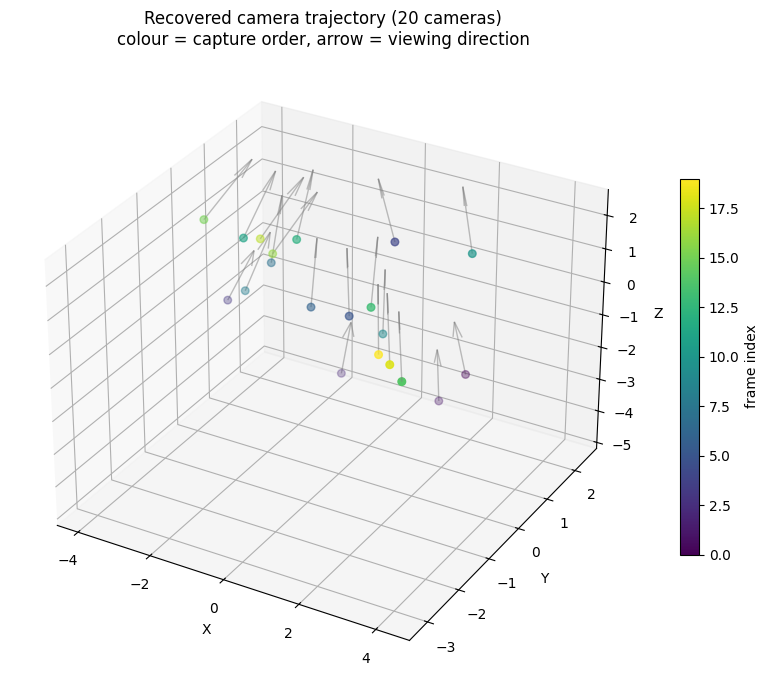

In [34]:
centres = []
forward_dirs = []
names = []
for img_id, img in sorted(rec.images.items(), key=lambda kv: kv[1].name):
    pose = img.cam_from_world()
    R = np.array(pose.rotation.matrix(), dtype=np.float64)  # world-to-camera
    t = np.array(pose.translation, dtype=np.float64)
    C = -R.T @ t                                  # camera centre in world
    forward = R.T @ np.array([0.0, 0.0, 1.0])    # camera +Z in world (looking direction)
    centres.append(C)
    forward_dirs.append(forward)
    names.append(img.name)
centres = np.array(centres)
forward_dirs = np.array(forward_dirs)

# Scale the forward arrows to be visible without overwhelming the plot
if len(centres) > 1:
    spacing = np.linalg.norm(np.diff(centres, axis=0), axis=1).mean()
else:
    spacing = 1.0
arrow_len = 0.5 * spacing

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(centres[:, 0], centres[:, 1], centres[:, 2],
                c=range(len(centres)), cmap="viridis", s=30)
for C, f in zip(centres, forward_dirs):
    ax.quiver(C[0], C[1], C[2],
              f[0] * arrow_len, f[1] * arrow_len, f[2] * arrow_len,
              color="gray", alpha=0.5, linewidth=1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
title = f"Recovered camera trajectory ({len(centres)} cameras)"
ax.set_title(title + chr(10) + "colour = capture order, arrow = viewing direction")
plt.colorbar(sc, ax=ax, shrink=0.6, label="frame index")
plt.tight_layout()
plt.show()

**Inspect:**
- Is the overall shape what you expected? A loop, an arc, a line?
- Are there gaps where consecutive frames are missing? Those are frames COLMAP rejected.
- Does the trajectory close (start near end)? If you walked all the way around, it should.

## Step 3. Reproject sparse 3D points back into a frame

This is the analog of the reprojection check from Lab 2. For one chosen frame, we project every visible 3D point through the recovered camera model and compare to the 2D feature location COLMAP actually recorded. If the model is self-consistent, the two land within a pixel of each other.

In [35]:
def build_K_and_dist(camera):
    """Return an OpenCV-style K matrix and distortion vector for pycolmap.Camera."""
    K = np.array(camera.calibration_matrix(), dtype=np.float64)
    dist = np.zeros(5, dtype=np.float64)
    return K, dist

In [36]:
# Pick a frame to inspect. Change FRAME_INDEX to look at a different one.
FRAME_INDEX = 5
img_obj = sorted(rec.images.values(), key=lambda im: im.name)[FRAME_INDEX]
camera = rec.cameras[img_obj.camera_id]
print(f"Inspecting frame: {img_obj.name}")

K, dist = build_K_and_dist(camera)

# Gather visible 3D points + their recorded 2D positions for this frame
points3d, detected2d = [], []
for p2d in img_obj.points2D:
    if p2d.has_point3D() and p2d.point3D_id in rec.points3D:
        points3d.append(rec.points3D[p2d.point3D_id].xyz)
        detected2d.append(p2d.xy)
points3d = np.array(points3d, dtype=np.float64)
detected2d = np.array(detected2d, dtype=np.float64)
print(f"Visible 3D points in this frame: {len(points3d)}")

# Project them through the recovered model
pose = img_obj.cam_from_world()
R = np.array(pose.rotation.matrix(), dtype=np.float64)
tvec = np.array(pose.translation, dtype=np.float64).reshape(3, 1)
rvec, _ = cv2.Rodrigues(R)
projected2d, _ = cv2.projectPoints(points3d, rvec, tvec, K, dist)
projected2d = projected2d.reshape(-1, 2)

errors_px = np.linalg.norm(projected2d - detected2d, axis=1)
print(f"Mean reproj error in this frame:   {errors_px.mean():.3f} px")
print(f"Median reproj error in this frame: {np.median(errors_px):.3f} px")
print(f"Max reproj error in this frame:    {errors_px.max():.3f} px")

Inspecting frame: frame_0006.jpg
Visible 3D points in this frame: 418
Mean reproj error in this frame:   0.750 px
Median reproj error in this frame: 0.579 px
Max reproj error in this frame:    3.365 px


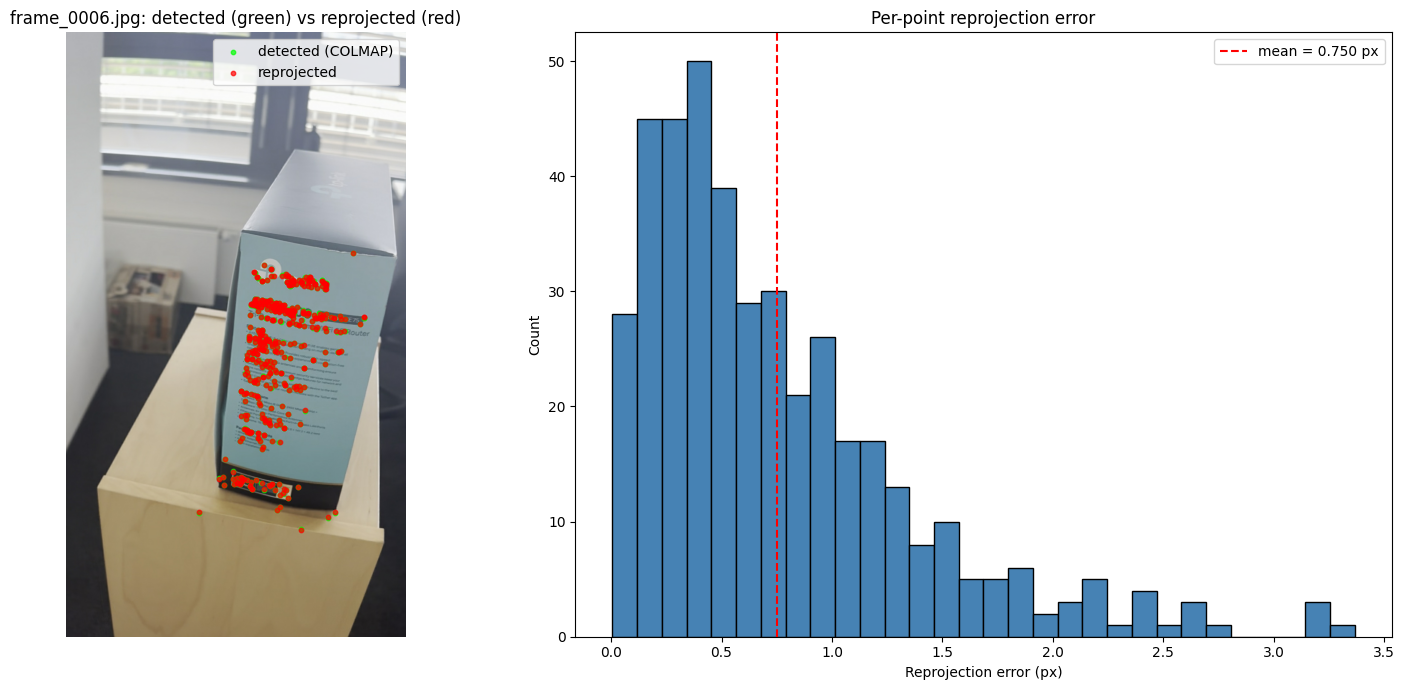

In [37]:
# Load the corresponding undistorted image
img_path = RECON_DIR / "dense" / "images" / img_obj.name
assert img_path.exists(), f"Missing image: {img_path}"
image_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(image_rgb)
axes[0].scatter(detected2d[:, 0], detected2d[:, 1], s=10, c="lime",
                label="detected (COLMAP)", alpha=0.7)
axes[0].scatter(projected2d[:, 0], projected2d[:, 1], s=10, c="red",
                label="reprojected", alpha=0.7)
axes[0].set_title(f"{img_obj.name}: detected (green) vs reprojected (red)")
axes[0].legend(loc="upper right")
axes[0].axis("off")

axes[1].hist(errors_px, bins=30, color="steelblue", edgecolor="black")
axes[1].axvline(errors_px.mean(), color="red", linestyle="--",
                label=f"mean = {errors_px.mean():.3f} px")
axes[1].set_xlabel("Reprojection error (px)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-point reprojection error")
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 4. Verify the epipolar constraint on a pair of frames

Pick two frames. The recovered poses give us a relative pose $\mathbf{R}_{LR}, \mathbf{t}_{LR}$, which lets us build the essential matrix

$$\mathbf{E} = [\mathbf{t}_{LR}]_\times \, \mathbf{R}_{LR}$$

For matched points $p_L$ and $p_R$ in normalized coordinates, $p_R^\top \mathbf{E}\, p_L = 0$. In pixel coordinates this becomes $p_R^\top \mathbf{F}\, p_L = 0$, with $\mathbf{F} = \mathbf{K}_R^{-\top} \mathbf{E}\, \mathbf{K}_L^{-1}$.

We evaluate the perpendicular distance from each $p_R$ to its epipolar line $\mathbf{F} p_L$, in pixels, and draw the epipolar lines on both frames.

In [38]:
# Pick two frames with shared sparse points. Change indices to inspect other pairs.
FRAME_L_INDEX = 5
FRAME_R_INDEX = 15

images_sorted = sorted(rec.images.values(), key=lambda im: im.name)
img_L = images_sorted[FRAME_L_INDEX]
img_R = images_sorted[FRAME_R_INDEX]
cam_L = rec.cameras[img_L.camera_id]
cam_R = rec.cameras[img_R.camera_id]
K_L, _ = build_K_and_dist(cam_L)
K_R, _ = build_K_and_dist(cam_R)
print(f"Left  frame: {img_L.name}")
print(f"Right frame: {img_R.name}")

# Relative pose: transform points from L's camera frame to R's camera frame
pose_L = img_L.cam_from_world()
pose_R = img_R.cam_from_world()
R_L = np.array(pose_L.rotation.matrix(), dtype=np.float64)
t_L = np.array(pose_L.translation, dtype=np.float64)
R_R = np.array(pose_R.rotation.matrix(), dtype=np.float64)
t_R = np.array(pose_R.translation, dtype=np.float64)
R_rel = R_R @ R_L.T
t_rel = t_R - R_rel @ t_L

def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])

E = skew(t_rel) @ R_rel
F = np.linalg.inv(K_R).T @ E @ np.linalg.inv(K_L)

# Find sparse points seen by both frames
ids_L = {p.point3D_id for p in img_L.points2D if p.has_point3D()}
ids_R = {p.point3D_id for p in img_R.points2D if p.has_point3D()}
shared = list(ids_L & ids_R)
print(f"Sparse points visible in both frames: {len(shared)}")
assert len(shared) > 0, "No shared points; pick frames closer together."

# Evaluate the constraint on a sample
rng = np.random.default_rng(0)
sample_ids = rng.choice(shared, size=min(5, len(shared)), replace=False).tolist()

print()
print("Perpendicular distance from p_R to its epipolar line F p_L (pixels):")
pairs_L, pairs_R = [], []
for p3d_id in sample_ids:
    pL_xy = next(p.xy for p in img_L.points2D if p.point3D_id == p3d_id)
    pR_xy = next(p.xy for p in img_R.points2D if p.point3D_id == p3d_id)
    pL_h = np.append(pL_xy, 1.0)
    pR_h = np.append(pR_xy, 1.0)
    line = F @ pL_h  # epipolar line in the right image
    a, b, c = line
    distance = abs(a * pR_xy[0] + b * pR_xy[1] + c) / np.sqrt(a * a + b * b)
    print(f"  point {p3d_id}: {distance:.3f} px")
    pairs_L.append(pL_xy)
    pairs_R.append(pR_xy)

Left  frame: frame_0006.jpg
Right frame: frame_0034.jpg
Sparse points visible in both frames: 30

Perpendicular distance from p_R to its epipolar line F p_L (pixels):
  point 353: 0.662 px
  point 215: 0.004 px
  point 419: 1.851 px
  point 167: 4.467 px
  point 362: 1.830 px


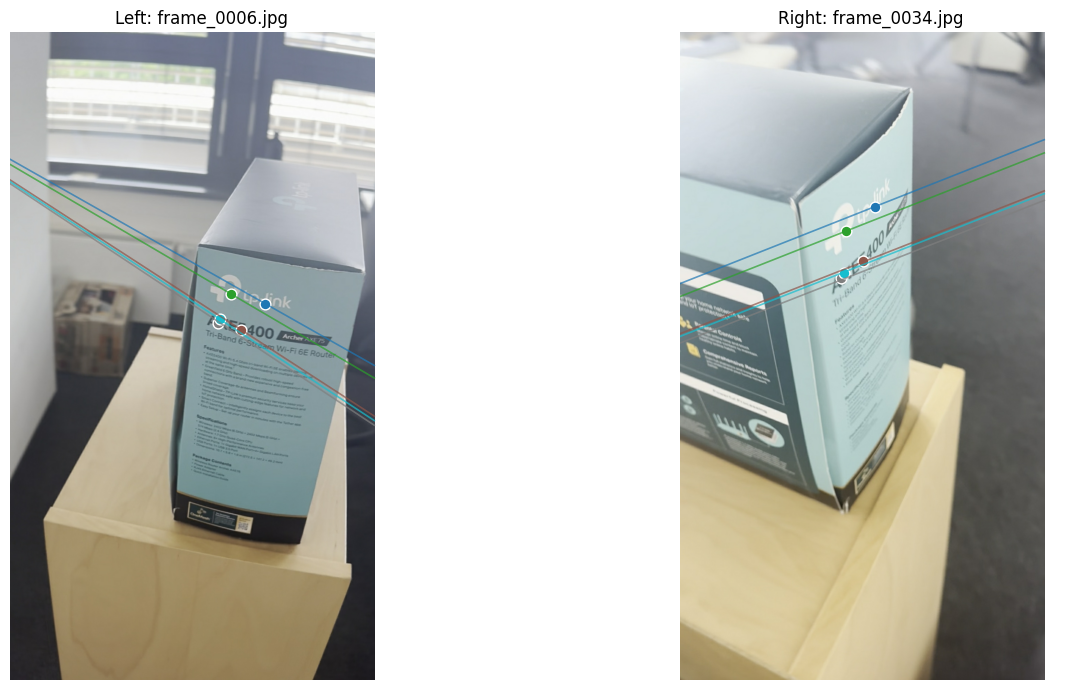

In [39]:
# Visualize: matched points + epipolar lines on both frames
imL = cv2.cvtColor(cv2.imread(str(RECON_DIR / "dense" / "images" / img_L.name)), cv2.COLOR_BGR2RGB)
imR = cv2.cvtColor(cv2.imread(str(RECON_DIR / "dense" / "images" / img_R.name)), cv2.COLOR_BGR2RGB)

def draw_line(ax, line, img_shape, color):
    a, b, c = line
    h, w = img_shape[:2]
    if abs(b) > 1e-8:
        y0 = -c / b
        y1 = -(a * w + c) / b
        ax.plot([0, w], [y0, y1], color=color, alpha=0.7, linewidth=1.2)
    elif abs(a) > 1e-8:
        x = -c / a
        ax.plot([x, x], [0, h], color=color, alpha=0.7, linewidth=1.2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(imL); axes[0].set_title(f"Left: {img_L.name}"); axes[0].axis("off")
axes[1].imshow(imR); axes[1].set_title(f"Right: {img_R.name}"); axes[1].axis("off")

colors = plt.cm.tab10(np.linspace(0, 1, len(pairs_L)))
for pL_xy, pR_xy, color in zip(pairs_L, pairs_R, colors):
    axes[0].scatter(*pL_xy, c=[color], s=60, edgecolor="white", linewidth=1)
    axes[1].scatter(*pR_xy, c=[color], s=60, edgecolor="white", linewidth=1)
    # Epipolar line in right image for pL
    pL_h = np.append(pL_xy, 1.0)
    draw_line(axes[1], F @ pL_h, imR.shape, color)
    # Epipolar line in left image for pR (transpose of F)
    pR_h = np.append(pR_xy, 1.0)
    draw_line(axes[0], F.T @ pR_h, imL.shape, color)

plt.tight_layout()
plt.show()

Each coloured dot in the left image has a matching coloured dot in the right image and a matching coloured epipolar line. The dot should lie on the line. The numerical distances above are how far the dot actually is from the line, in pixels.

## Step 5. Inspect the dense point cloud

Read the dense fused point cloud directly from the PLY file and show a lightweight interactive Plotly preview. The plot is subsampled so it stays responsive inside the notebook.

In [40]:
def read_ply_header(file_obj):
    header = []
    while True:
        line = file_obj.readline()
        if not line:
            raise ValueError("Invalid PLY file: missing end_header")
        decoded = line.decode("ascii").strip()
        header.append(decoded)
        if decoded == "end_header":
            return header


def ply_element_count(path, element_name):
    with open(path, "rb") as f:
        header = read_ply_header(f)
    for line in header:
        parts = line.split()
        if len(parts) == 3 and parts[:2] == ["element", element_name]:
            return int(parts[2])
    return 0


def read_ply_vertices(path):
    """Read vertex xyz and optional RGB from a simple ascii or binary little-endian PLY."""
    dtype_map = {
        "char": "i1", "int8": "i1",
        "uchar": "u1", "uint8": "u1",
        "short": "<i2", "int16": "<i2",
        "ushort": "<u2", "uint16": "<u2",
        "int": "<i4", "int32": "<i4",
        "uint": "<u4", "uint32": "<u4",
        "float": "<f4", "float32": "<f4",
        "double": "<f8", "float64": "<f8",
    }

    with open(path, "rb") as f:
        header = read_ply_header(f)
        if not header or header[0] != "ply":
            raise ValueError(f"Not a PLY file: {path}")

        format_line = next(line for line in header if line.startswith("format "))
        ply_format = format_line.split()[1]

        vertex_count = 0
        properties = []
        in_vertex = False
        for line in header:
            parts = line.split()
            if len(parts) == 3 and parts[:2] == ["element", "vertex"]:
                vertex_count = int(parts[2])
                in_vertex = True
            elif len(parts) >= 2 and parts[0] == "element":
                in_vertex = False
            elif in_vertex and len(parts) >= 3 and parts[0] == "property" and parts[1] != "list":
                properties.append((parts[2], parts[1]))  # name, type

        if vertex_count == 0:
            return np.empty((0, 3)), None

        if ply_format == "binary_little_endian":
            dtype = np.dtype([(name, dtype_map[type_name]) for name, type_name in properties])
            data = np.fromfile(f, dtype=dtype, count=vertex_count)
            columns = {name: data[name] for name, _ in properties}
        elif ply_format == "ascii":
            table = np.loadtxt(f, max_rows=vertex_count)
            if table.ndim == 1:
                table = table[None, :]
            columns = {name: table[:, i] for i, (name, _) in enumerate(properties)}
        else:
            raise ValueError(f"Unsupported PLY format: {ply_format}")

    points = np.column_stack([columns["x"], columns["y"], columns["z"]]).astype(np.float64)
    colors = None
    if all(name in columns for name in ("red", "green", "blue")):
        colors = np.column_stack([columns["red"], columns["green"], columns["blue"]]).astype(np.float64) / 255.0
    return points, colors


def plot_point_cloud_preview(points, colors=None, max_points=20000, title="Point cloud preview"):
    if len(points) == 0:
        raise ValueError("No points to plot")

    rng = np.random.default_rng(0)
    if len(points) > max_points:
        idx = rng.choice(len(points), size=max_points, replace=False)
        pts = points[idx]
        cols = colors[idx] if colors is not None else None
    else:
        pts = points
        cols = colors

    if cols is not None:
        marker_color = [f"rgb({int(255*r)},{int(255*g)},{int(255*b)})" for r, g, b in cols]
        marker = dict(size=1.2, color=marker_color, opacity=0.85)
    else:
        marker = dict(size=1.2, color=pts[:, 2], colorscale="Viridis", opacity=0.85,
                      colorbar=dict(title="Z"))

    fig = go.Figure(data=[go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=marker,
    )])
    fig.update_layout(
        title=f"{title}<br>showing {len(pts):,} of {len(points):,} vertices",
        height=700,
        margin=dict(l=0, r=0, b=0, t=55),
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
    )
    fig.show()


fused_path = RECON_DIR / "dense" / "fused.ply"
assert fused_path.exists(), f"Missing: {fused_path}"
points, colors = read_ply_vertices(fused_path)
print(f"Dense cloud: {len(points):,} points")
plot_point_cloud_preview(points, colors, title="Dense fused point cloud")

Dense cloud: 51,234 points


**What to look for:**
- Surfaces with rich texture should be cleanly reconstructed.
- Reflective, transparent, or uniformly coloured surfaces are typically full of holes or noise.
- Regions only seen from a small range of viewpoints are usually thinner and noisier.

## Step 6. Inspect the mesh

The Colab notebook already ran Poisson reconstruction on the dense cloud. Here we avoid a 3D GUI dependency and preview the mesh vertices with Matplotlib, while also reporting the number of faces stored in the PLY.

In [41]:
mesh_path = RECON_DIR / "dense" / "meshed.ply"
assert mesh_path.exists(), f"Missing: {mesh_path}"
mesh_points, mesh_colors = read_ply_vertices(mesh_path)
mesh_faces = ply_element_count(mesh_path, "face")
print(f"Mesh: {len(mesh_points):,} vertices, {mesh_faces:,} faces")
plot_point_cloud_preview(mesh_points, mesh_colors, title="Poisson mesh vertex preview")

Mesh: 66,487 vertices, 129,556 faces
